# Sri Lanka Tourism Analysis — Exploratory Data Analysis (EDA)
In this step, the clean dataset is loaded, and its basic structure, statistics, and patterns are explored before performing any deeper analysis.

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# T0 makes charts appear inside the notebook 
%matplotlib inline

# This sets a clean visual style for all charts automatically
sns.set_theme(style='whitegrid')


Load Clean Dataset

In [3]:
# Load the CSV file
df = pd.read_csv('sl_tourism_clean.csv')

print("Shape:", df.shape)        
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()                         

Shape: (16068, 5)

Column names: ['Year', 'Month', 'Country', 'Number_of_Tourists', 'Date']

Data types:
 Year                   int64
Month                 object
Country               object
Number_of_Tourists     int64
Date                  object
dtype: object

First 5 rows:


,Year,Month,Country,Number_of_Tourists,Date
0,2019,January,Afghanistan,49,2019-01
1,2019,January,Albania,48,2019-01
2,2019,January,Algeria,34,2019-01
3,2019,January,Andorra,2,2019-01
4,2019,January,Angola,4,2019-01


Check for Any Remaining Issues

In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print(df.duplicated().sum())

print("\n=== Basic Statistics ===")
df['Number_of_Tourists'].describe()

=== Missing Values ===
Year                  0
Month                 0
Country               0
Number_of_Tourists    0
Date                  0
dtype: int64

=== Duplicate Rows ===
0

=== Basic Statistics ===


count    16068.000000
mean       575.003921
std       2774.195370
min          0.000000
25%          0.000000
50%          5.000000
75%        104.000000
max      56715.000000
Name: Number_of_Tourists, dtype: float64

What years and months are there?

In [5]:
print("Years in dataset:", sorted(df['Year'].unique()))

print("\nMonths in dataset:", df['Month'].unique().tolist())

print("\nRows per year:")
print(df.groupby('Year')['Number_of_Tourists'].count())

Years in dataset: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Months in dataset: ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

Rows per year:
Year
2019    2328
2020    2256
2021    2280
2022    2256
2023    2280
2024    2316
2025    2352
Name: Number_of_Tourists, dtype: int64


 Total Arrivals Per Year

In [6]:
# Group by year and sum all tourist numbers
yearly_totals = df.groupby('Year')['Number_of_Tourists'].sum().reset_index()


yearly_totals.columns = ['Year', 'Total_Arrivals']

print(yearly_totals)

   Year  Total_Arrivals
0  2019         1913702
1  2020          507699
2  2021          194495
3  2022          719978
4  2023         1487303
5  2024         2053465
6  2025         2362521


##### Total Arrivals Per Year

This chart shows how tourist arrivals changed year by year.
Key events visible: Easter Sunday Attacks (2019), COVID-19 (2020-2021), Recovery (2022-2025).

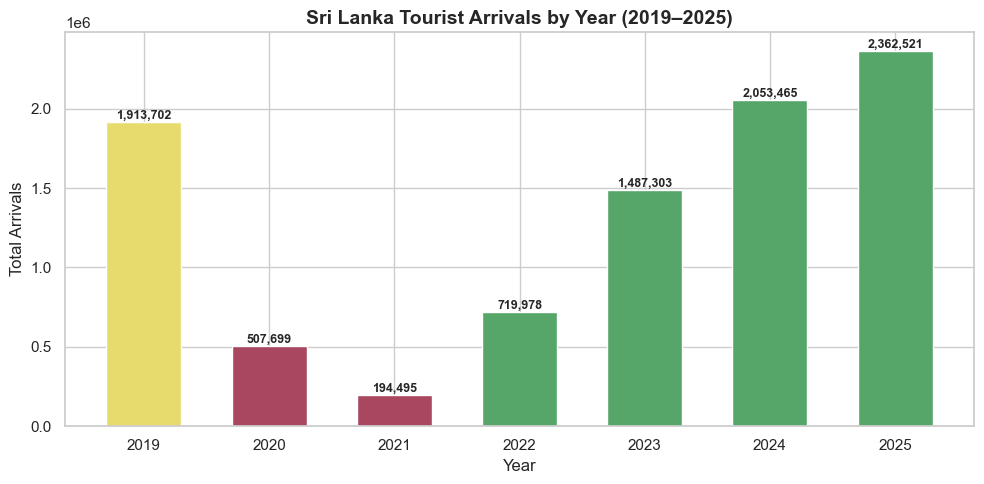

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = []
for year in yearly_totals['Year']:
    if year == 2019:
        colors.append("#e7db6e")   
    elif year in [2020, 2021]:
        colors.append("#a8475f")   
    else:
        colors.append("#56A66A")   

ax.bar(yearly_totals['Year'], yearly_totals['Total_Arrivals'],
       color=colors, width=0.6, edgecolor='white')

for i, row in yearly_totals.iterrows():
    ax.text(row['Year'], row['Total_Arrivals'] + 20000,
            f"{row['Total_Arrivals']:,}",   
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('Sri Lanka Tourist Arrivals by Year (2019–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Arrivals')
ax.set_xticks(yearly_totals['Year'])   

plt.tight_layout()   
plt.show()

##### Top 10 Countries Overall

In [8]:
top10 = (df.groupby('Country')['Number_of_Tourists']
           .sum()
           .sort_values(ascending=False)
           .head(10)
           .reset_index())

top10.columns = ['Country', 'Total_Tourists']
print(top10)

              Country  Total_Tourists
0               India         1874960
1      United Kingdom          876768
2  Russian Federation          830110
3             Germany          623979
4               China          533647
5           Australia          414798
6              France          408559
7       United States          285877
8              Canada          225378
9            Maldives          216552


##### Sanity Check on the Data

In [9]:
# Check the months with zero arrivals 
zero_months = df[df['Number_of_Tourists'] == 0]

print(f"Rows with 0 arrivals: {len(zero_months)}")
print("\nZero arrival months by year:")
print(zero_months.groupby('Year')['Month'].nunique())

Rows with 0 arrivals: 4988

Zero arrival months by year:
Year
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
Name: Month, dtype: int64


In [ ]:
# Better check 
monthly_totals = df.groupby(['Year', 'Month'])['Number_of_Tourists'].sum().reset_index()

# Months where the TOTAL across all countries is 0
truly_empty = monthly_totals[monthly_totals['Number_of_Tourists'] == 0]

print(f"Months where Sri Lanka got ZERO tourists from ALL countries: {len(truly_empty)}")
print(truly_empty)

Months where Sri Lanka got ZERO tourists from ALL countries: 8
    Year      Month  Number_of_Tourists
12  2020      April                   0
13  2020     August                   0
17  2020       July                   0
18  2020       June                   0
20  2020        May                   0
21  2020   November                   0
22  2020    October                   0
23  2020  September                   0


In [ ]:
# Verify COVID impact

monthly_totals['Date'] = monthly_totals.apply(
    lambda row: f"{int(row['Year'])}-{['January','February','March','April','May','June','July','August','September','October','November','December'].index(row['Month'])+1:02d}",
    axis=1
)

monthly_totals = monthly_totals.sort_values('Date')

# Show the 10 lowest months in the entire dataset
print("=== 10 Lowest Months (should be COVID period) ===")
print(monthly_totals.nsmallest(10, 'Number_of_Tourists')[['Year', 'Month', 'Number_of_Tourists']])

# Show the 10 highest months
print("\n=== 10 Highest Months (should be pre-COVID or 2024/2025) ===")
print(monthly_totals.nlargest(10, 'Number_of_Tourists')[['Year', 'Month', 'Number_of_Tourists']])

=== 10 Lowest Months (should be COVID period) ===
    Year      Month  Number_of_Tourists
12  2020      April                   0
20  2020        May                   0
18  2020       June                   0
17  2020       July                   0
13  2020     August                   0
23  2020  September                   0
22  2020    October                   0
21  2020   November                   0
14  2020   December                 393
32  2021        May                1497

=== 10 Highest Months (should be pre-COVID or 2024/2025) ===
    Year     Month  Number_of_Tourists
74  2025  December              258928
76  2025   January              252761
3   2019  February              252033
62  2024  December              248592
7   2019     March              244328
4   2019   January              244239
2   2019  December              241663
75  2025  February              240217
79  2025     March              229298
16  2020   January              228433
